# ANN vs SNN Comparative Study on FER2013

Comparative evaluation of a ResNet18 baseline (ANN) and a SEW-ResNet18 spiking neural network (SNN)
on the FER2013 facial emotion recognition dataset.

**References**
- Fang et al. (2021). *Deep Residual Learning in Spiking Neural Networks*. NeurIPS 2021.
- Fang et al. (2021). *Incorporating Learnable Membrane Time Constants*. ICCV 2021.
- Horowitz (2014). *Computing's Energy Problem*. IEEE ISSCC 2014.
- Lemaire et al. (2022). *An Analytical Estimation of SNN Energy Efficiency*.

## 1. Imports and Environment Setup

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
import time
from collections import Counter
from datetime import datetime
from tqdm import tqdm
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from spikingjelly.activation_based import neuron, functional
from snn_model import create_sew_resnet18, reset_snn_state, test_sew_resnet

warnings.filterwarnings('ignore')
np.int = int
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"Session started : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"PyTorch         : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name()}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/dieudo/anaconda3/envs/env_snn/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Session started : 2026-05-03 22:10:26
PyTorch         : 2.11.0+cu130
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU memory      : 6.1 GB


## 2. GPU Energy Monitoring

In [3]:
try:
    import pynvml
    pynvml.nvmlInit()
    gpu_handle     = pynvml.nvmlDeviceGetHandleByIndex(0)
    gpu_monitoring = True

    def get_gpu_power_usage():
        return pynvml.nvmlDeviceGetPowerUsage(gpu_handle) / 1000

    def get_gpu_memory_usage():
        return pynvml.nvmlDeviceGetMemoryInfo(gpu_handle).used / 1024**3

    gpu_name_raw = pynvml.nvmlDeviceGetName(gpu_handle)
    gpu_name     = gpu_name_raw.decode('utf-8') if isinstance(gpu_name_raw, bytes) else gpu_name_raw
    power_limit  = pynvml.nvmlDeviceGetPowerManagementLimitConstraints(gpu_handle)[1] / 1000
    total_mem    = pynvml.nvmlDeviceGetMemoryInfo(gpu_handle).total / 1024**3
    print(f"GPU monitoring enabled : {gpu_name} ({power_limit:.0f}W, {total_mem:.1f}GB)")

except Exception as e:
    gpu_monitoring = False
    def get_gpu_power_usage():  return 0
    def get_gpu_memory_usage(): return 0
    print(f"GPU monitoring disabled : {e}")

GPU monitoring enabled : NVIDIA GeForce RTX 3050 6GB Laptop GPU (95W, 6.0GB)


## 3. Model Definitions

In [4]:
def create_baseline_ann(num_classes=7):
    """
    ResNet18 adapted for FER2013 (grayscale 48x48, 7 classes).
    Uses ImageNet pretrained weights averaged to single channel.
    Progressive dropout (0.1->0.2->0.3) and extended classifier head.
    Label smoothing applied at loss level (see Section 4).
    """
    model  = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    weight = model.conv1.weight.clone()

    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.conv1.weight.data = weight.mean(dim=1, keepdim=True)
    model.maxpool = nn.Identity()

    model.layer2 = nn.Sequential(nn.Dropout2d(0.1), *model.layer2)
    model.layer3 = nn.Sequential(nn.Dropout2d(0.2), *model.layer3)
    model.layer4 = nn.Sequential(nn.Dropout2d(0.3), *model.layer4)

    model.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model


def get_model_info(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total_params': total, 'trainable_params': trainable}


# Validate SEW-ResNet18 forward pass
print("Validating SEW-ResNet18...")
assert test_sew_resnet(), "SEW-ResNet18 validation failed"
print("SEW-ResNet18 ready.")

Validating SEW-ResNet18...
Running SEW-ResNet18 validation tests...
[create_sew_resnet18] Architecture  : SEW-ResNet18 (SpikingJelly)
[create_sew_resnet18] Parameters    : 11,173,831
[create_sew_resnet18] Timesteps     : 4
[create_sew_resnet18] SpikingJelly  : True
  Input  : torch.Size([2, 1, 48, 48])
  Output : torch.Size([2, 7])  —  PASS ✓
SEW-ResNet18 ready.


## 4. Experiment Configuration

In [5]:
class ExperimentConfig:
    """
    Centralized hyperparameter configuration.
    Modify DATASET_PATH to point to your FER2013 directory.
    Expected structure: data/train/<class>/*.jpg, data/test/<class>/*.jpg
    """
    def __init__(self):
        # Dataset
        self.dataset_path    = "/home/dieudo/ProjectsLIN/neuromorphic-emotion-recognition/data"
        self.num_classes     = 7

        # SNN architecture
        self.snn_architecture = "SEW-ResNet18"
        self.snn_timesteps    = 8       # T — direct encoding, replicated T times
        self.snn_encoding     = "direct"

        # Training
        self.epochs       = 30
        self.batch_size   = 16
        self.ann_lr       = 3e-4
        self.snn_lr       = 1e-4
        self.weight_decay = 1e-3
        self.patience     = 10
        self.save_best_models = True

        # Output
        self.results_dir    = "sew_resnet18_results"
        self.timestamp      = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.experiment_dir = f"{self.results_dir}/{self.timestamp}"

    def validate(self):
        errors = []
        if not os.path.exists(self.dataset_path):
            errors.append(f"Dataset path not found: {self.dataset_path}")
        if self.epochs <= 0 or self.batch_size <= 0:
            errors.append("epochs and batch_size must be positive")
        if self.ann_lr <= 0 or self.snn_lr <= 0:
            errors.append("Learning rates must be positive")
        if self.snn_timesteps <= 0:
            errors.append("snn_timesteps must be positive")
        return len(errors) == 0, errors


config = ExperimentConfig()
is_valid, errors = config.validate()
if not is_valid:
    raise ValueError(f"Invalid config: {errors}")

os.makedirs(config.experiment_dir, exist_ok=True)
with open(f"{config.experiment_dir}/config.json", 'w') as f:
    json.dump(vars(config), f, indent=2, default=str)

print(f"Experiment directory : {config.experiment_dir}")
for k, v in vars(config).items():
    print(f"  {k:<20}: {v}")

Experiment directory : sew_resnet18_results/20260430_132106
  dataset_path        : /home/dieudo/ProjectsLIN/neuromorphic-emotion-recognition/data
  num_classes         : 7
  snn_architecture    : SEW-ResNet18
  snn_timesteps       : 8
  snn_encoding        : direct
  epochs              : 30
  batch_size          : 16
  ann_lr              : 0.0003
  snn_lr              : 0.0001
  weight_decay        : 0.001
  patience            : 10
  save_best_models    : True
  results_dir         : sew_resnet18_results
  timestamp           : 20260430_132106
  experiment_dir      : sew_resnet18_results/20260430_132106


## 5. Data Loading and Class Balancing

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Data augmentation
# Normalize with FER2013 grayscale statistics (mean=0.499, std=0.266)
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((50, 50)),
    transforms.RandomCrop(48),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.499,), (0.266,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.499,), (0.266,))
])

# Dataset loading
train_dataset = ImageFolder(root=f"{config.dataset_path}/train", transform=transform_train)
test_dataset  = ImageFolder(root=f"{config.dataset_path}/test",  transform=transform_test)

print(f"Training set : {len(train_dataset)} images")
print(f"Test set     : {len(test_dataset)} images")
print(f"Classes      : {train_dataset.classes}")

# Class distribution
class_counts  = Counter([label for _, label in train_dataset.samples])
total_images  = sum(class_counts.values())
imbalance_ratio = max(class_counts.values()) / min(class_counts.values())

print("\nClass distribution:")
for i, name in enumerate(train_dataset.classes):
    print(f"  {name:<12}: {class_counts[i]:5d} ({100*class_counts[i]/total_images:.1f}%)")
print(f"\nImbalance ratio : {imbalance_ratio:.1f}:1")

# Inverse-frequency class weights for loss and sampler
class_weights_list = [total_images / class_counts[i] for i in range(len(train_dataset.classes))]
class_weights_arr  = np.array(class_weights_list)
class_weights_arr  = class_weights_arr / class_weights_arr.sum() * len(class_weights_arr)
class_weights      = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

print("\nClass weights (normalized inverse frequency):")
for i, w in enumerate(class_weights):
    print(f"  {train_dataset.classes[i]:<12}: {w.item():.4f}")

# Loss functions
# ANN : label smoothing 0.1 reduces overconfidence on ambiguous classes (fear, sad)
# SNN : no label smoothing — surrogate gradient already noisy
criterion_ann = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
criterion_snn = nn.CrossEntropyLoss(weight=class_weights)

# Weighted random sampler for balanced mini-batches
sample_weights = [1.0 / class_counts[label] for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                          sampler=sampler, num_workers=4,
                          pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=config.batch_size,
                          shuffle=False, num_workers=4,
                          pin_memory=True, drop_last=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Device : cuda
Training set : 28709 images
Test set     : 7178 images
Classes      : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class distribution:
  angry       :  3995 (13.9%)
  disgust     :   436 (1.5%)
  fear        :  4097 (14.3%)
  happy       :  7215 (25.1%)
  neutral     :  4965 (17.3%)
  sad         :  4830 (16.8%)
  surprise    :  3171 (11.0%)

Imbalance ratio : 16.5:1

Class weights (normalized inverse frequency):
  angry       : 0.4800
  disgust     : 4.3982
  fear        : 0.4681
  happy       : 0.2658
  neutral     : 0.3862
  sad         : 0.3970
  surprise    : 0.6047

Train batches : 1794
Test batches  : 449


## 6. Training Function

In [7]:
def train_model(model, model_name, train_loader, test_loader, config, device, criterion):
    """
    Unified training loop for ANN and SNN with energy monitoring and early stopping.

    Optimizer : AdamW for both architectures.
    Scheduler : CosineAnnealingLR — T_max doubled for SNN to prevent premature LR decay.
    Gradient clipping : max_norm=1.0 for stability with surrogate gradients.
    """
    print(f"\nTRAINING {model_name}")
    print("-" * 30)

    # Optimizer
    lr           = config.ann_lr if model_name == "ANN" else config.snn_lr
    weight_decay = config.weight_decay if model_name == "ANN" else 1e-4
    optimizer    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Scheduler — longer cycle for SNN (LR must stay high while spike patterns form)
    t_max     = config.epochs if model_name == "ANN" else config.epochs * 2
    eta_min   = 1e-6 if model_name == "ANN" else 1e-5
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max, eta_min=eta_min)

    history = {
        'train_losses': [], 'train_accs': [],
        'val_losses':   [], 'val_accs':   [],
        'learning_rates': [], 'power_usage': [], 'memory_usage': []
    }

    best_val_acc    = 0.0
    best_epoch      = 0
    patience_counter = 0

    for epoch in range(config.epochs):
        epoch_start       = time.time()
        memory_start      = get_gpu_memory_usage()
        epoch_power_samples = []

        # --- Training phase ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        train_pbar = tqdm(train_loader,
                          desc=f"{model_name} Epoch {epoch+1:2d} [Train]",
                          leave=False)

        for batch_idx, (data, target) in enumerate(train_pbar):
            data, target = (data.to(device, non_blocking=True),
                            target.to(device, non_blocking=True))

            if batch_idx % 20 == 0 and gpu_monitoring:
                epoch_power_samples.append(get_gpu_power_usage())

            optimizer.zero_grad()
            try:
                output = model(data)
                loss   = criterion(output, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss    += loss.item()
                pred           = output.argmax(dim=1)
                train_correct += (pred == target).sum().item()
                train_total   += target.size(0)

                postfix = {'Loss': f'{loss.item():.4f}',
                           'Acc':  f'{train_correct/train_total:.3f}'}
                if gpu_monitoring and epoch_power_samples:
                    postfix['Power'] = f'{sum(epoch_power_samples)/len(epoch_power_samples):.1f}W'
                train_pbar.set_postfix(postfix)

            except Exception as e:
                print(f"Batch {batch_idx} error: {e}")
                continue

        avg_train_loss  = train_loss / len(train_loader)
        train_accuracy  = train_correct / train_total

        # --- Validation phase ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels = [], []

        val_pbar = tqdm(test_loader,
                        desc=f"{model_name} Epoch {epoch+1:2d} [Val]",
                        leave=False)

        with torch.no_grad():
            for data, target in val_pbar:
                data, target = (data.to(device, non_blocking=True),
                                target.to(device, non_blocking=True))
                try:
                    output     = model(data)
                    loss       = criterion(output, target)
                    val_loss  += loss.item()
                    pred       = output.argmax(dim=1)
                    val_correct += (pred == target).sum().item()
                    val_total   += target.size(0)
                    all_preds.extend(pred.cpu().numpy())
                    all_labels.extend(target.cpu().numpy())
                    val_pbar.set_postfix({'Loss': f'{loss.item():.4f}',
                                         'Acc':  f'{val_correct/val_total:.3f}'})
                except Exception as e:
                    print(f"Validation error: {e}")
                    continue

        avg_val_loss   = val_loss / len(test_loader)
        val_accuracy   = val_correct / val_total
        val_f1         = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

        # Energy metrics
        avg_epoch_power  = (sum(epoch_power_samples) / len(epoch_power_samples)
                            if gpu_monitoring and epoch_power_samples else 0)
        avg_epoch_memory = (memory_start + get_gpu_memory_usage()) / 2 if gpu_monitoring else 0

        scheduler.step()

        history['train_losses'].append(avg_train_loss)
        history['train_accs'].append(train_accuracy)
        history['val_losses'].append(avg_val_loss)
        history['val_accs'].append(val_accuracy)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        history['power_usage'].append(avg_epoch_power)
        history['memory_usage'].append(avg_epoch_memory)

        epoch_time = time.time() - epoch_start
        line = (f"{model_name} Epoch {epoch+1:2d}: "
                f"Train Loss {avg_train_loss:.4f}, Acc {train_accuracy:.3f} | "
                f"Val Loss {avg_val_loss:.4f}, Acc {val_accuracy:.3f}, F1 {val_f1:.3f}")
        if gpu_monitoring:
            line += f" | {avg_epoch_power:.1f}W {avg_epoch_memory:.1f}GB"
        line += f" | {epoch_time:.1f}s"
        print(line)

        # Checkpointing
        if val_accuracy > best_val_acc:
            best_val_acc     = val_accuracy
            best_epoch       = epoch
            patience_counter = 0
            if config.save_best_models:
                torch.save({'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'best_val_acc': best_val_acc},
                           f"{config.experiment_dir}/best_{model_name.lower()}_model.pth")
                print(f"  Checkpoint saved: {best_val_acc:.3f}")
        else:
            patience_counter += 1

        if patience_counter >= config.patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"\n{model_name} — Best accuracy: {best_val_acc:.3f} at epoch {best_epoch+1}")

    history.update({
        'best_val_acc' : best_val_acc,
        'best_epoch'   : best_epoch,
        'final_preds'  : all_preds,
        'final_labels' : all_labels,
        'model_info'   : get_model_info(model),
        'avg_power'    : (sum(history['power_usage']) / len(history['power_usage'])
                         if history['power_usage'] else 0),
        'max_power'    : max(history['power_usage']) if history['power_usage'] else 0,
        'avg_memory'   : (sum(history['memory_usage']) / len(history['memory_usage'])
                         if history['memory_usage'] else 0)
    })
    return history

## 7. ANN Baseline Training

In [8]:
print("=" * 50)
print("ANN BASELINE — ResNet18")
print("=" * 50)

ann_model  = create_baseline_ann(num_classes=config.num_classes).to(device)
ann_params = get_model_info(ann_model)['total_params']
print(f"Parameters : {ann_params:,}")

ann_results = train_model(
    model=ann_model, model_name="ANN",
    train_loader=train_loader, test_loader=test_loader,
    config=config, device=device, criterion=criterion_ann
)

baseline_performance = {
    'accuracy'  : ann_results['best_val_acc'],
    'epoch'     : ann_results['best_epoch'],
    'parameters': ann_params
}
print(f"ANN best accuracy : {ann_results['best_val_acc']:.3f} ({ann_results['best_val_acc']*100:.1f}%)")

ANN BASELINE — ResNet18
Parameters : 11,303,879

TRAINING ANN
------------------------------


ANN Epoch  1: Train Loss 1.4770, Acc 0.171 | Val Loss 2.5202, Acc 0.100, F1 0.059 | 58.9W 2.4GB | 83.5s
  Checkpoint saved: 0.100


ANN Epoch  2: Train Loss 1.2069, Acc 0.288 | Val Loss 2.0606, Acc 0.345, F1 0.341 | 59.6W 2.5GB | 83.4s
  Checkpoint saved: 0.345


ANN Epoch  3: Train Loss 1.0861, Acc 0.409 | Val Loss 1.9529, Acc 0.439, F1 0.440 | 59.5W 2.5GB | 83.6s
  Checkpoint saved: 0.439


ANN Epoch  4: Train Loss 0.9802, Acc 0.483 | Val Loss 1.8371, Acc 0.513, F1 0.508 | 59.6W 2.6GB | 83.8s
  Checkpoint saved: 0.513


...

ANN Epoch 26: Train Loss 0.6250, Acc 0.787 | Val Loss 1.6105, Acc 0.665, F1 0.665 | 59.5W 2.8GB | 81.4s


ANN Epoch 27: Train Loss 0.6244, Acc 0.787 | Val Loss 1.5932, Acc 0.664, F1 0.665 | 59.6W 2.8GB | 81.4s


ANN Epoch 28: Train Loss 0.6121, Acc 0.785 | Val Loss 1.5913, Acc 0.667, F1 0.667 | 59.6W 2.8GB | 83.5s
  Checkpoint saved: 0.667


ANN Epoch 29: Train Loss 0.6229, Acc 0.788 | Val Loss 1.5962, Acc 0.668, F1 0.669 | 59.6W 2.8GB | 82.1s
  Checkpoint saved: 0.668


ANN Epoch 30: Train Loss 0.6199, Acc 0.792 | Val Loss 1.5937, Acc 0.668, F1 0.670 | 59.6W 2.8GB | 82.1s

ANN — Best accuracy: 0.668 at epoch 29
ANN best accuracy : 0.668 (66.8%)


## 8. SEW-ResNet18 SNN Training

In [9]:
print("=" * 50)
print("SNN — SEW-ResNet18 (SpikingJelly)")
print("=" * 50)

snn_model = create_sew_resnet18(
    num_classes=config.num_classes,
    num_timesteps=config.snn_timesteps,
    encoding_type=config.snn_encoding
).to(device)

assert snn_model.is_spikingjelly, "SpikingJelly backend not loaded — check snn_model.py"

model_info  = snn_model.get_architecture_info()
snn_params  = model_info['total_parameters']
param_ratio = max(ann_params, snn_params) / min(ann_params, snn_params)

print(f"Parameters    : {snn_params:,}")
print(f"Timesteps (T) : {config.snn_timesteps}")
print(f"Param ratio   : {param_ratio:.2f}:1  "
      f"({'balanced' if param_ratio < 2 else 'acceptable' if param_ratio < 5 else 'WARNING'})")

snn_results = train_model(
    model=snn_model, model_name="SNN",
    train_loader=train_loader, test_loader=test_loader,
    config=config, device=device, criterion=criterion_snn
)

ann_best_acc  = ann_results['best_val_acc']
snn_best_acc  = snn_results['best_val_acc']
performance_ratio = snn_best_acc / ann_best_acc if ann_best_acc > 0 else 0

print(f"\nComparative results:")
print(f"  ANN : {ann_best_acc:.3f} ({ann_best_acc*100:.1f}%)")
print(f"  SNN : {snn_best_acc:.3f} ({snn_best_acc*100:.1f}%)")
print(f"  SNN/ANN ratio : {performance_ratio:.2f}")

SNN — SEW-ResNet18 (SpikingJelly)
[create_sew_resnet18] Architecture  : SEW-ResNet18 (SpikingJelly)
[create_sew_resnet18] Parameters    : 11,173,831
[create_sew_resnet18] Timesteps     : 8
[create_sew_resnet18] SpikingJelly  : True
Parameters    : 11,173,831
Timesteps (T) : 8
Param ratio   : 1.01:1  (balanced)

TRAINING SNN
------------------------------


SNN Epoch  1: Train Loss 1.4337, Acc 0.173 | Val Loss 2.5604, Acc 0.056, F1 0.042 | 58.2W 3.0GB | 129.0s
  Checkpoint saved: 0.056


SNN Epoch  2: Train Loss 1.2167, Acc 0.252 | Val Loss 2.1214, Acc 0.144, F1 0.097 | 34.6W 3.1GB | 129.9s
  Checkpoint saved: 0.144


SNN Epoch  3: Train Loss 1.1112, Acc 0.300 | Val Loss 1.9500, Acc 0.209, F1 0.166 | 34.1W 3.0GB | 129.7s
  Checkpoint saved: 0.209


SNN Epoch  4: Train Loss 1.0590, Acc 0.349 | Val Loss 1.9077, Acc 0.262, F1 0.256 | 34.1W 2.9GB | 129.3s
  Checkpoint saved: 0.262


...

SNN Epoch 26: Train Loss 0.5507, Acc 0.615 | Val Loss 1.3120, Acc 0.527, F1 0.522 | 33.3W 2.8GB | 126.6s
  Checkpoint saved: 0.527


SNN Epoch 27: Train Loss 0.5438, Acc 0.620 | Val Loss 1.2720, Acc 0.534, F1 0.535 | 33.2W 2.8GB | 126.7s
  Checkpoint saved: 0.534


SNN Epoch 28: Train Loss 0.5293, Acc 0.627 | Val Loss 1.3266, Acc 0.521, F1 0.519 | 33.4W 2.7GB | 126.3s


SNN Epoch 29: Train Loss 0.5220, Acc 0.632 | Val Loss 1.2686, Acc 0.537, F1 0.536 | 44.5W 2.8GB | 128.0s
  Checkpoint saved: 0.537


SNN Epoch 30: Train Loss 0.5135, Acc 0.633 | Val Loss 1.2781, Acc 0.538, F1 0.542 | 57.3W 2.9GB | 129.2s
  Checkpoint saved: 0.538

SNN — Best accuracy: 0.538 at epoch 30

Comparative results:
  ANN : 0.668 (66.8%)
  SNN : 0.538 (53.8%)
  SNN/ANN ratio : 0.81


## 9. SNN Spike Activity Analysis (AFR and SynOps)

In [10]:
print("Running SNN spike activity analysis...")

spike_dict   = {}
hook_handles = []
lif_names    = []

def make_hook(key):
    def hook_fn(module, input, output):
        if isinstance(output, torch.Tensor):
            spike_dict[key] = output.detach().cpu()
    return hook_fn

for name, module in snn_model.backbone.named_modules():
    if isinstance(module, (neuron.LIFNode, neuron.IFNode)):
        hook_handles.append(module.register_forward_hook(make_hook(name)))
        lif_names.append(name)

print(f"Hooks registered on {len(hook_handles)} LIF/IF layers")
assert len(hook_handles) > 0, "No LIFNode found — is_spikingjelly must be True"

# Verify on one batch
snn_model.eval()
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    _ = snn_model(imgs.to(device))
assert len(spike_dict) > 0, "Hooks registered but nothing captured"
first_key = list(spike_dict.keys())[0]
print(f"Verification OK — {first_key}: shape {spike_dict[first_key].shape}")

# Fan-in dictionary for SynOps computation
# Conv2d: fan_in = C_in x kH x kW  |  Linear: fan_in = in_features
fan_in_dict = {}
for name, module in snn_model.backbone.named_modules():
    if isinstance(module, nn.Conv2d):
        fan_in_dict[name] = (module.weight.shape[1] *
                             module.weight.shape[2] *
                             module.weight.shape[3])
    elif isinstance(module, nn.Linear):
        fan_in_dict[name] = module.weight.shape[1]

def resolve_conv_key(lif_name):
    """Map LIF layer name to its preceding Conv layer (SEW-ResNet18 naming)."""
    if 'downsample_sn' in lif_name:
        return lif_name.replace('downsample_sn', 'downsample.0')
    return (lif_name.replace('sn1', 'conv1')
                    .replace('sn2', 'conv2')
                    .replace('sn',  'conv'))

# Full test-set analysis
total_spikes  = 0
total_neurons = 0
total_synops  = 0
total_images  = 0
layer_stats   = {k: [0, 0] for k in lif_names}

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        total_images += images.shape[0]
        spike_dict.clear()
        _ = snn_model(images)

        for layer_name, layer_output in spike_dict.items():
            spikes  = layer_output.sum().item()
            neurons = layer_output.numel()
            T, B    = layer_output.shape[0], layer_output.shape[1]

            total_spikes  += spikes
            total_neurons += neurons
            if layer_name in layer_stats:
                layer_stats[layer_name][0] += spikes
                layer_stats[layer_name][1] += neurons

            fan_in        = fan_in_dict.get(resolve_conv_key(layer_name), 1)
            total_synops += (spikes / (T * B)) * fan_in

# Global metrics
afr              = total_spikes / total_neurons
sparsity         = 1 - afr
synops_per_image = total_synops / total_images
MAC_AC_RATIO     = 3.7  # Horowitz (2014), 45nm CMOS

print("\n" + "=" * 55)
print("SNN SPIKE METRICS — GLOBAL")
print("=" * 55)
print(f"  Images analyzed     : {total_images:,}")
print(f"  Total spikes        : {total_spikes:.4e}")
print(f"  Average Firing Rate : {afr:.4f}  ({afr*100:.2f}%)")
print(f"  Sparsity            : {sparsity:.4f}  ({sparsity*100:.2f}%)")
print(f"  SynOps / image      : {synops_per_image:.4e}")
print(f"  AFR status          : ", end="")
if   afr < 0.01: print("LOW  — increase T or check normalization")
elif afr > 0.30: print("HIGH — reduce LR or increase weight_decay")
else:            print("NORMAL [1%–30%] ✓")

# Per-layer AFR table
rows = []
for name, (s, n) in layer_stats.items():
    if n > 0:
        layer_afr = s / n
        fan_in    = fan_in_dict.get(resolve_conv_key(name), 1)
        status    = "low" if layer_afr < 0.01 else "high" if layer_afr > 0.30 else "normal"
        rows.append({'Layer': name, 'AFR': round(layer_afr, 4),
                     'Sparsity': f"{(1-layer_afr)*100:.2f}%",
                     'Fan-in': fan_in, 'Status': status})

print("\n" + "=" * 55)
print("AFR PER LIF LAYER")
print("=" * 55)
print(pd.DataFrame(rows).to_string(index=False))

# Energy efficiency
print("\n" + "=" * 55)
print("ENERGY EFFICIENCY ANALYSIS")
print("=" * 55)
print(f"  SynOps / image         : {synops_per_image:.4e}")
print(f"  MAC/AC ratio           : {MAC_AC_RATIO}x  (Horowitz, 2014 — 45nm CMOS)")
print(f"  Theoretical saving     : {(1-1/MAC_AC_RATIO)*100:.1f}%  (neuromorphic hardware)")
print(f"  ANN GPU power          : {ann_results['avg_power']:.1f}W")
print(f"  SNN GPU power          : {snn_results['avg_power']:.1f}W")
print(f"  Measured GPU saving    : "
      f"{(1-snn_results['avg_power']/ann_results['avg_power'])*100:.1f}%")
print(f"  Note: GPU saving is low — GPUs are optimized for dense computation.")
print(f"        On Loihi/SpiNNaker, saving would reach ~{(1-1/MAC_AC_RATIO)*100:.0f}%.")

for handle in hook_handles:
    handle.remove()
print("\nHooks released.")

Running SNN spike activity analysis...
Hooks registered on 20 LIF/IF layers
Verification OK — sn1: shape torch.Size([8, 16, 64, 24, 24])

SNN SPIKE METRICS — GLOBAL
  Images analyzed     : 7,178
  Total spikes        : 3.9810e+08
  Average Firing Rate : 0.0585  (5.85%)
  Sparsity            : 0.9415  (94.15%)
  SynOps / image      : 3.2481e+05
  AFR status          : NORMAL [1%–30%] ✓

AFR PER LIF LAYER
                 Layer    AFR Sparsity  Fan-in Status
                   sn1 0.0647   93.53%      49 normal
          layer1.0.sn1 0.0613   93.87%     576 normal
          layer1.0.sn2 0.0557   94.43%     576 normal
          layer1.1.sn1 0.0590   94.10%     576 normal
          layer1.1.sn2 0.0525   94.75%     576 normal
          layer2.0.sn1 0.0679   93.21%     576 normal
          layer2.0.sn2 0.0653   93.47%    1152 normal
layer2.0.downsample_sn 0.0608   93.92%      64 normal
          layer2.1.sn1 0.0532   94.68%    1152 normal
          layer2.1.sn2 0.0457   95.43%    1152 normal

## 10. Visualizations

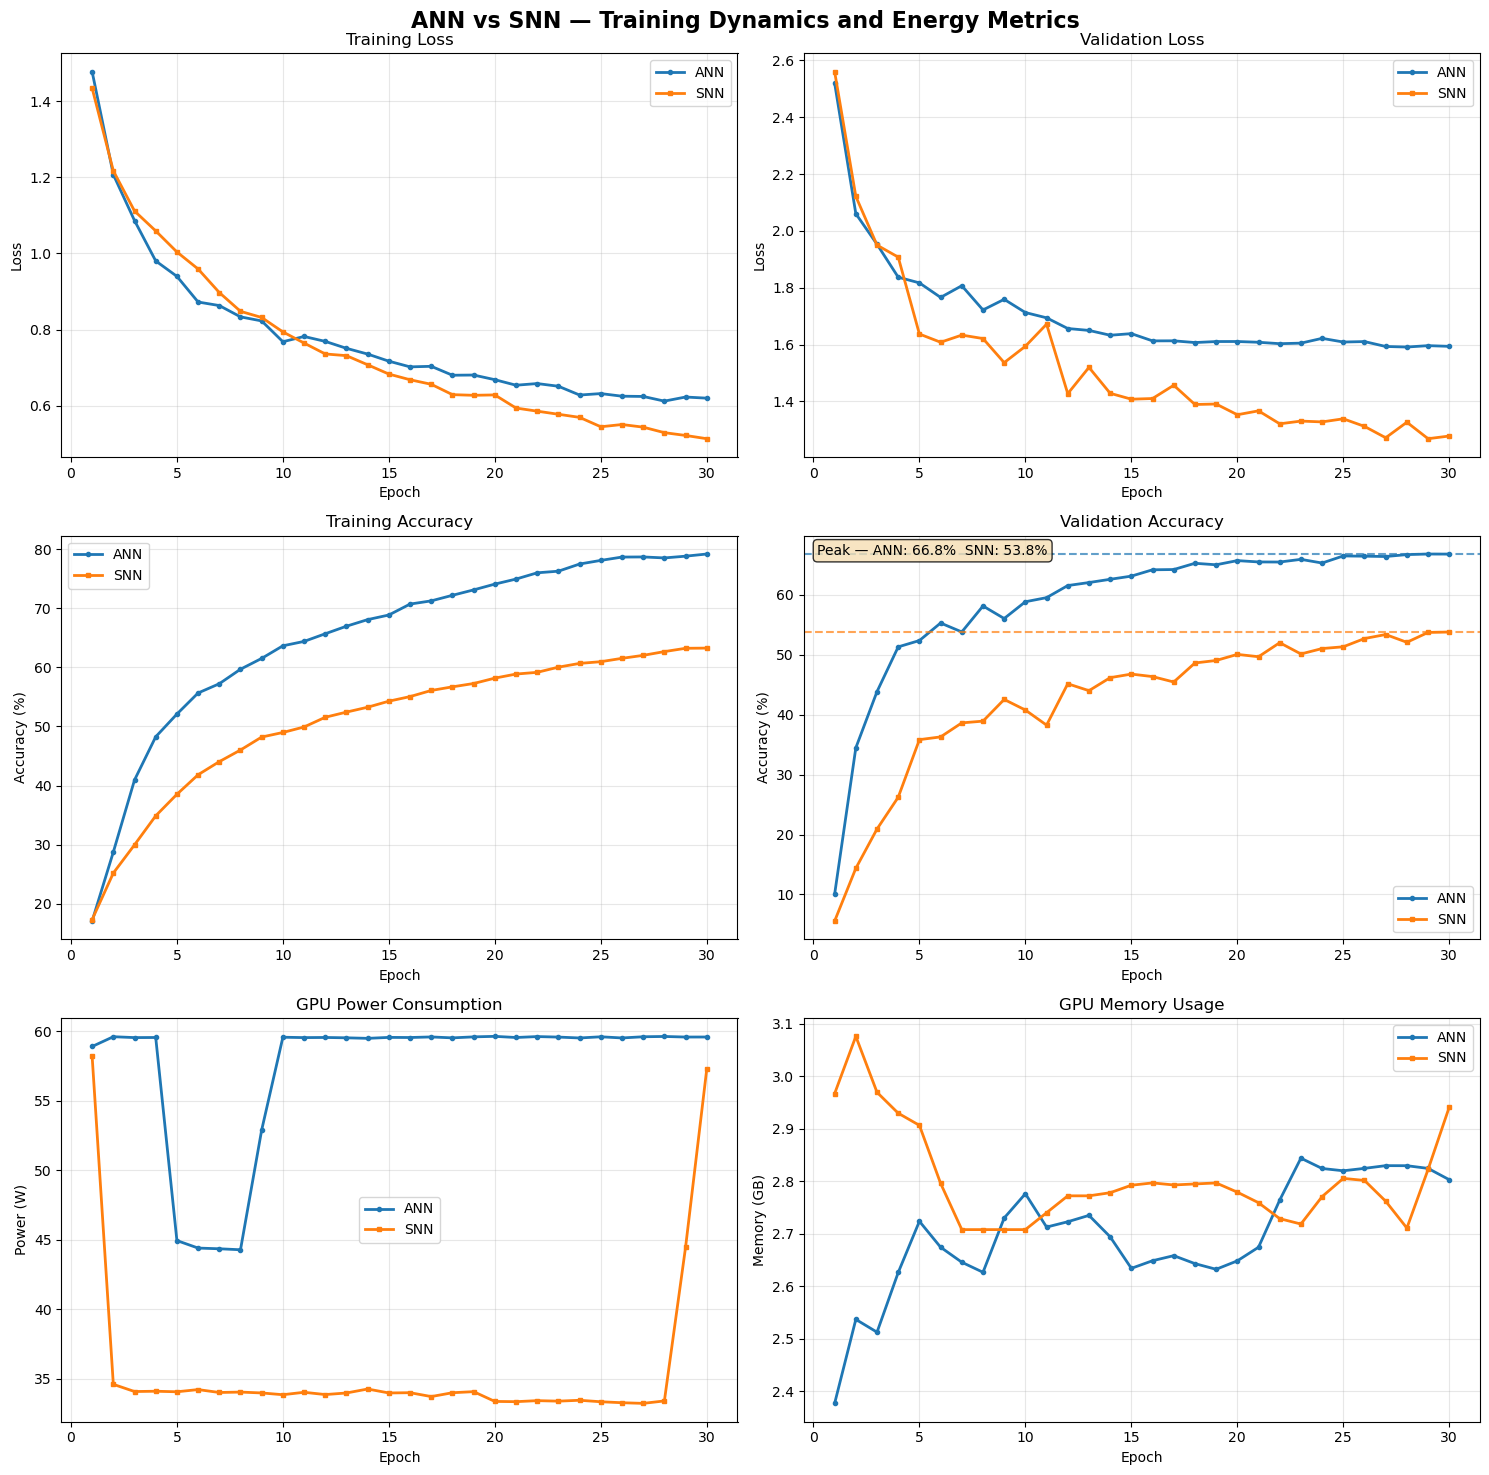

In [11]:
colors = {'ann': '#1f77b4', 'snn': '#ff7f0e'}
ann_epochs = range(1, len(ann_results['train_losses']) + 1)
snn_epochs = range(1, len(snn_results['train_losses']) + 1)

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('ANN vs SNN — Training Dynamics and Energy Metrics',
             fontsize=16, fontweight='bold')

def plot_metric(ax, ann_vals, snn_vals, ylabel, title, multiply=1):
    ax.plot(ann_epochs, [v*multiply for v in ann_vals],
            color=colors['ann'], lw=2, marker='o', ms=3, label='ANN')
    ax.plot(snn_epochs, [v*multiply for v in snn_vals],
            color=colors['snn'], lw=2, marker='s', ms=3, label='SNN')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

plot_metric(axes[0,0], ann_results['train_losses'], snn_results['train_losses'],
            'Loss', 'Training Loss')
plot_metric(axes[0,1], ann_results['val_losses'],   snn_results['val_losses'],
            'Loss', 'Validation Loss')
plot_metric(axes[1,0], ann_results['train_accs'],   snn_results['train_accs'],
            'Accuracy (%)', 'Training Accuracy', multiply=100)
plot_metric(axes[1,1], ann_results['val_accs'],     snn_results['val_accs'],
            'Accuracy (%)', 'Validation Accuracy', multiply=100)

ann_max = max(ann_results['val_accs'])*100
snn_max = max(snn_results['val_accs'])*100
axes[1,1].axhline(ann_max, color=colors['ann'], ls='--', alpha=0.7)
axes[1,1].axhline(snn_max, color=colors['snn'], ls='--', alpha=0.7)
axes[1,1].text(0.02, 0.98, f'Peak — ANN: {ann_max:.1f}%  SNN: {snn_max:.1f}%',
               transform=axes[1,1].transAxes, va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

if gpu_monitoring:
    plot_metric(axes[2,0], ann_results['power_usage'], snn_results['power_usage'],
                'Power (W)', 'GPU Power Consumption')
    plot_metric(axes[2,1], ann_results['memory_usage'], snn_results['memory_usage'],
                'Memory (GB)', 'GPU Memory Usage')

plt.tight_layout()
plt.savefig(f"{config.experiment_dir}/training_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

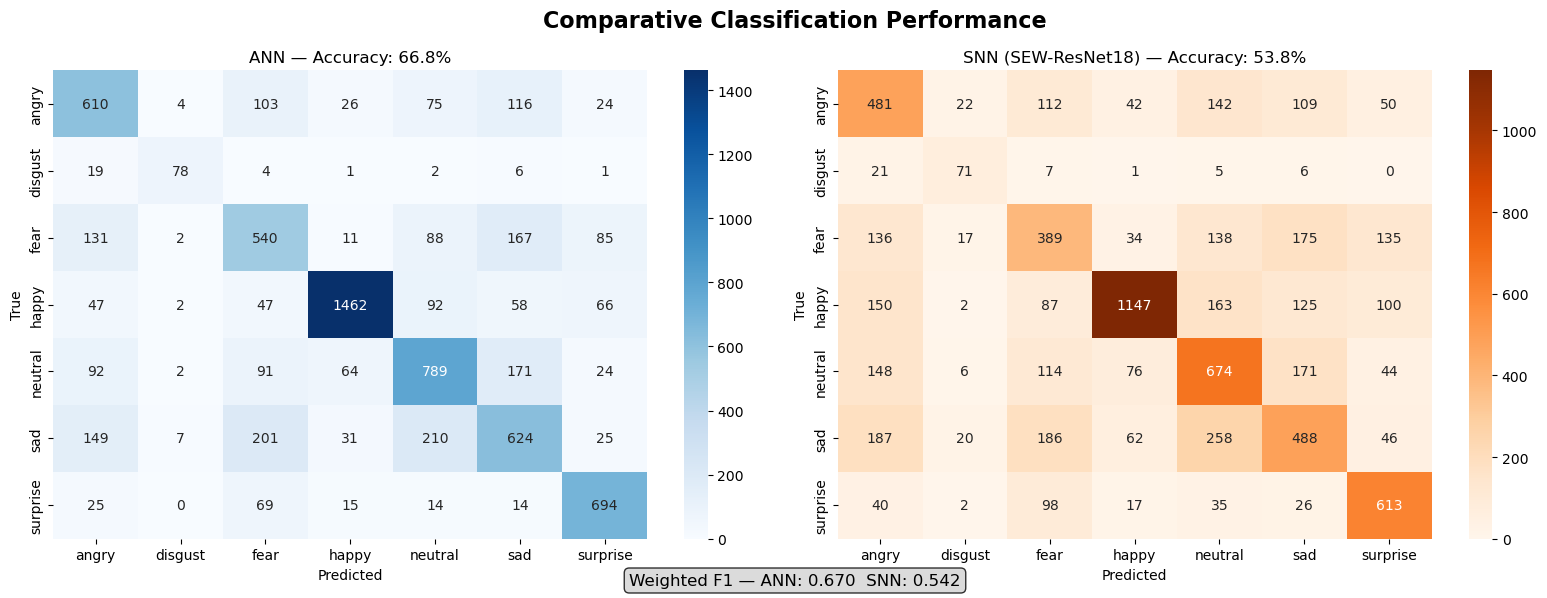

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparative Classification Performance', fontsize=16, fontweight='bold')

cm_ann = confusion_matrix(ann_results['final_labels'], ann_results['final_preds'])
cm_snn = confusion_matrix(snn_results['final_labels'], snn_results['final_preds'])

sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=ax1)
ax1.set_title(f'ANN — Accuracy: {ann_results["best_val_acc"]*100:.1f}%')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

sns.heatmap(cm_snn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=ax2)
ax2.set_title(f'SNN (SEW-ResNet18) — Accuracy: {snn_results["best_val_acc"]*100:.1f}%')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

ann_f1 = f1_score(ann_results['final_labels'], ann_results['final_preds'], average='weighted', zero_division=0)
snn_f1 = f1_score(snn_results['final_labels'], snn_results['final_preds'], average='weighted', zero_division=0)
fig.text(0.5, 0.02, f'Weighted F1 — ANN: {ann_f1:.3f}  SNN: {snn_f1:.3f}',
         ha='center', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{config.experiment_dir}/confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

## 11. Classification Report

In [13]:
def print_classification_report(results, model_name, class_names):
    report = classification_report(results['final_labels'], results['final_preds'],
                                   target_names=class_names, zero_division=0,
                                   output_dict=True)
    print(f"\n{model_name}")
    print("=" * 60)
    acc  = report['accuracy']
    w_f1 = report['weighted avg']['f1-score']
    m_f1 = report['macro avg']['f1-score']
    print(f"  Accuracy         : {acc:.3f} ({acc*100:.1f}%)")
    print(f"  Weighted F1      : {w_f1:.3f}")
    print(f"  Macro F1         : {m_f1:.3f}")
    print(f"\n  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*52}")
    for cls in class_names:
        m = report[cls]
        print(f"  {cls:<12} {m['precision']:>10.3f} {m['recall']:>10.3f} "
              f"{m['f1-score']:>10.3f} {int(m['support']):>10}")
    return report

ann_report = print_classification_report(ann_results, "ANN BASELINE", train_dataset.classes)
snn_report = print_classification_report(snn_results, "SNN (SEW-ResNet18)", train_dataset.classes)

print("\nPER-CLASS F1 COMPARISON")
print("=" * 60)
print(f"  {'Class':<12} {'ANN F1':>8} {'SNN F1':>8} {'Diff':>8} {'Winner':>8}")
print(f"  {'-'*48}")
for cls in train_dataset.classes:
    af1 = ann_report[cls]['f1-score']
    sf1 = snn_report[cls]['f1-score']
    winner = 'ANN' if af1 >= sf1 else 'SNN'
    print(f"  {cls:<12} {af1:>8.3f} {sf1:>8.3f} {sf1-af1:>+8.3f} {winner:>8}")


ANN BASELINE
  Accuracy         : 0.668 (66.8%)
  Weighted F1      : 0.670
  Macro F1         : 0.669

  Class         Precision     Recall         F1    Support
  ----------------------------------------------------
  angry             0.568      0.637      0.601        958
  disgust           0.821      0.703      0.757        111
  fear              0.512      0.527      0.519       1024
  happy             0.908      0.824      0.864       1774
  neutral           0.621      0.640      0.630       1233
  sad               0.540      0.500      0.519       1247
  surprise          0.755      0.835      0.793        831

SNN (SEW-ResNet18)
  Accuracy         : 0.538 (53.8%)
  Weighted F1      : 0.542
  Macro F1         : 0.533

  Class         Precision     Recall         F1    Support
  ----------------------------------------------------
  angry             0.414      0.502      0.454        958
  disgust           0.507      0.640      0.566        111
  fear              0.392  

## 12. Results Export

In [14]:
summary = {
    'experiment': {
        'timestamp'       : config.timestamp,
        'dataset'         : 'FER2013',
        'train_images'    : len(train_dataset),
        'test_images'     : len(test_dataset),
        'classes'         : train_dataset.classes,
        'imbalance_ratio' : float(imbalance_ratio)
    },
    'models': {
        'ann': {'architecture': 'ResNet18 (pretrained ImageNet)',
                'parameters': ann_params,
                'lr': config.ann_lr},
        'snn': {'architecture': config.snn_architecture,
                'parameters': snn_params,
                'lr': config.snn_lr,
                'timesteps': config.snn_timesteps,
                'encoding': config.snn_encoding}
    },
    'performance': {
        'ann_accuracy'     : float(ann_best_acc),
        'snn_accuracy'     : float(snn_best_acc),
        'snn_ann_ratio'    : float(performance_ratio),
        'ann_f1_weighted'  : float(ann_f1),
        'snn_f1_weighted'  : float(snn_f1)
    },
    'spike_metrics': {
        'afr'              : float(afr),
        'sparsity'         : float(sparsity),
        'synops_per_image' : float(synops_per_image)
    },
    'energy': {
        'ann_avg_power_w'  : float(ann_results['avg_power']),
        'snn_avg_power_w'  : float(snn_results['avg_power']),
        'mac_ac_ratio'     : MAC_AC_RATIO,
        'theoretical_saving_pct': float((1 - 1/MAC_AC_RATIO) * 100)
    },
    'history': {
        'ann': {k: [float(v) for v in ann_results[k]]
                for k in ['train_losses','val_losses','train_accs','val_accs']},
        'snn': {k: [float(v) for v in snn_results[k]]
                for k in ['train_losses','val_losses','train_accs','val_accs']}
    }
}

with open(f"{config.experiment_dir}/summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

torch.save({'ann_results': ann_results, 'snn_results': snn_results,
            'summary': summary},
           f"{config.experiment_dir}/results.pth")

print(f"Results saved to : {config.experiment_dir}/")
print(f"  summary.json")
print(f"  results.pth")
print(f"  training_comparison.png")
print(f"  confusion_matrices.png")
print(f"  best_ann_model.pth")
print(f"  best_snn_model.pth")

Results saved to : sew_resnet18_results/20260430_132106/
  summary.json
  results.pth
  training_comparison.png
  confusion_matrices.png
  best_ann_model.pth
  best_snn_model.pth


## 13. Final Summary

In [15]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Completed : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Results   : {config.experiment_dir}")

print(f"\n  PERFORMANCE")
print(f"    ANN accuracy    : {ann_best_acc*100:.1f}%  (epoch {ann_results['best_epoch']+1})")
print(f"    SNN accuracy    : {snn_best_acc*100:.1f}%  (epoch {snn_results['best_epoch']+1})")
print(f"    SNN/ANN ratio   : {performance_ratio:.2f}")
print(f"    ANN F1 weighted : {ann_f1:.3f}")
print(f"    SNN F1 weighted : {snn_f1:.3f}")

print(f"\n  SPIKE METRICS")
print(f"    AFR             : {afr*100:.2f}%")
print(f"    Sparsity        : {sparsity*100:.2f}%")
print(f"    SynOps/image    : {synops_per_image:.4e}")

print(f"\n  ENERGY")
print(f"    ANN power (GPU) : {ann_results['avg_power']:.1f}W")
print(f"    SNN power (GPU) : {snn_results['avg_power']:.1f}W")
print(f"    Theoretical saving (neuromorphic) : {(1-1/MAC_AC_RATIO)*100:.1f}%")

print(f"\n  DATASET")
print(f"    Training images : {len(train_dataset):,}")
print(f"    Test images     : {len(test_dataset):,}")
print(f"    Classes         : {len(train_dataset.classes)}")
print(f"    Imbalance ratio : {imbalance_ratio:.1f}:1")
print("=" * 60)

EXPERIMENT SUMMARY
  Completed : 2026-04-30 15:08:15
  Results   : sew_resnet18_results/20260430_132106

  PERFORMANCE
    ANN accuracy    : 66.8%  (epoch 29)
    SNN accuracy    : 53.8%  (epoch 30)
    SNN/ANN ratio   : 0.81
    ANN F1 weighted : 0.670
    SNN F1 weighted : 0.542

  SPIKE METRICS
    AFR             : 5.85%
    Sparsity        : 94.15%
    SynOps/image    : 3.2481e+05

  ENERGY
    ANN power (GPU) : 57.3W
    SNN power (GPU) : 35.8W
    Theoretical saving (neuromorphic) : 73.0%

  DATASET
    Training images : 28,709
    Test images     : 7,178
    Classes         : 7
    Imbalance ratio : 16.5:1


In [19]:
# =================================================================
# SINGLE IMAGE INFERENCE — ANN vs SNN
# =================================================================

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path
from snn_model import create_sew_resnet18, reset_snn_state

CLASS_NAMES   = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
RESULTS_DIR   = "sew_resnet18_results"

TRANSFORM = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.499,), (0.266,))
])


def create_baseline_ann(num_classes=7):
    """ResNet18 adapted for grayscale FER2013 — matches training architecture."""
    model    = models.resnet18(weights=None)
    weight   = model.conv1.weight.clone()
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.conv1.weight.data = weight.mean(dim=1, keepdim=True)
    model.maxpool = nn.Identity()
    model.layer2  = nn.Sequential(nn.Dropout2d(0.1), *model.layer2)
    model.layer3  = nn.Sequential(nn.Dropout2d(0.2), *model.layer3)
    model.layer4  = nn.Sequential(nn.Dropout2d(0.3), *model.layer4)
    model.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model


def load_latest_checkpoints(ann_model, snn_model, device, results_dir=RESULTS_DIR):
    """Load weights from the most recent experiment directory."""
    results_path = Path(results_dir)
    if not results_path.exists():
        print("No results directory found — using untrained models.")
        return

    experiment_dirs = [d for d in results_path.iterdir() if d.is_dir()]
    if not experiment_dirs:
        print("No experiment subdirectory found.")
        return

    latest = max(experiment_dirs, key=lambda d: d.stat().st_mtime)

    for model, name in [(ann_model, "ann"), (snn_model, "snn")]:
        ckpt_path = latest / f"best_{name}_model.pth"
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location=device)
            model.load_state_dict(ckpt['model_state_dict'])
            print(f"  {name.upper()} checkpoint loaded — val_acc: "
                  f"{ckpt.get('best_val_acc', 0):.3f}  [{ckpt_path}]")
        else:
            print(f"  {name.upper()} checkpoint not found — using untrained weights.")


def predict(model, image_tensor, is_snn=False):
    """Run inference and return (class_index, confidence, probabilities)."""
    model.eval()
    with torch.no_grad():
        if is_snn:
            reset_snn_state(model)
        logits = model(image_tensor)
        probs  = torch.softmax(logits, dim=1)
        idx    = probs.argmax(dim=1).item()
        conf   = probs.max(dim=1)[0].item()
    return idx, conf, probs


def plot_comparison(image_tensor, true_class,
                    ann_pred, ann_conf, ann_probs,
                    snn_pred, snn_conf, snn_probs,
                    save_path="inference_result.png"):
    """Side-by-side terminal-style visualization of ANN vs SNN predictions."""

    img = (image_tensor.squeeze().cpu().numpy() * 0.266 + 0.499).clip(0, 1)

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.patch.set_facecolor('black')

    title = f"True label: {true_class}" if true_class else "ANN vs SNN"
    fig.suptitle(title, fontsize=15, color='white', y=0.97)

    ann_probs_np = ann_probs.squeeze().cpu().numpy()
    snn_probs_np = snn_probs.squeeze().cpu().numpy()

    panel_cfg = [
        (axes[0], "ANN",  ann_pred, ann_conf, ann_probs_np, 'lime',   'cyan'),
        (axes[1], "SNN",  snn_pred, snn_conf, snn_probs_np, 'orange', 'orange'),
    ]

    for ax, label, pred, conf, probs_np, color, title_color in panel_cfg:
        ax.imshow(img, cmap='viridis', aspect='equal')

        prob_text = "\n".join(f"{n}: {p*100:.1f}%"
                              for n, p in zip(CLASS_NAMES, probs_np))
        ax.text(0.02, 0.98, prob_text,
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top', color=color, fontfamily='monospace',
                bbox=dict(boxstyle='square,pad=0.4', facecolor='black',
                          edgecolor=color, linewidth=1))

        ax.text(0.03, 0.34, f"{CLASS_NAMES[pred]}  {conf:.1%}",
                transform=ax.transAxes, fontsize=13, fontweight='bold',
                verticalalignment='top', color=color, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='black',
                          edgecolor=color, linewidth=2))

        ax.set_title(label, color=title_color, fontsize=13, pad=8)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='black')
    plt.show()
    print(f"Saved : {save_path}")


def test_image(image_path, results_dir=RESULTS_DIR):
    """
    Run ANN and SNN inference on a single image.

    Args:
        image_path  (str): Path to the image file.
        results_dir (str): Directory containing experiment checkpoints.
    """
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Detect true class from directory name if available
    true_class = None
    for part in image_path.parts:
        if part.capitalize() in CLASS_NAMES:
            true_class = part.capitalize()
            break

    print(f"Device     : {device}")
    print(f"Image      : {image_path}")
    if true_class:
        print(f"True class : {true_class}")

    # Load and preprocess image
    image_tensor = TRANSFORM(Image.open(image_path)).unsqueeze(0).to(device)

    # Build and load models
    ann_model = create_baseline_ann(num_classes=len(CLASS_NAMES)).to(device)
    snn_model = create_sew_resnet18(num_classes=len(CLASS_NAMES)).to(device)
    load_latest_checkpoints(ann_model, snn_model, device, results_dir)

    # Inference
    ann_pred, ann_conf, ann_probs = predict(ann_model, image_tensor, is_snn=False)
    snn_pred, snn_conf, snn_probs = predict(snn_model, image_tensor, is_snn=True)

    # Console output
    print(f"\nPredictions :")
    if true_class:
        ann_correct = "✓" if CLASS_NAMES[ann_pred] == true_class else "✗"
        snn_correct = "✓" if CLASS_NAMES[snn_pred] == true_class else "✗"
        print(f"  ANN : {CLASS_NAMES[ann_pred]:10} ({ann_conf:.1%})  {ann_correct}")
        print(f"  SNN : {CLASS_NAMES[snn_pred]:10} ({snn_conf:.1%})  {snn_correct}")
    else:
        print(f"  ANN : {CLASS_NAMES[ann_pred]} ({ann_conf:.1%})")
        print(f"  SNN : {CLASS_NAMES[snn_pred]} ({snn_conf:.1%})")

    agreement = CLASS_NAMES[ann_pred] == CLASS_NAMES[snn_pred]
    print(f"  Agreement : {'Yes' if agreement else 'No'}")

    # Visualization
    plot_comparison(image_tensor, true_class,
                    ann_pred, ann_conf, ann_probs,
                    snn_pred, snn_conf, snn_probs)


def test_random_image(dataset_path):
    """Pick a random test image and run inference."""
    test_dir   = Path(dataset_path) / "test"
    extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    all_images = [p for cls_dir in test_dir.iterdir() if cls_dir.is_dir()
                  for p in cls_dir.iterdir() if p.suffix.lower() in extensions]

    if not all_images:
        raise FileNotFoundError(f"No images found in {test_dir}")

    chosen = np.random.choice(all_images)
    print(f"Random image : {chosen.name}  (class: {chosen.parent.name})")
    test_image(str(chosen))


Device     : cuda
Image      : /home/dieudo/ProjectsLIN/neuromorphic-emotion-recognition/data/train/disgust/Training_4844859.jpg
True class : Disgust
[create_sew_resnet18] Architecture  : SEW-ResNet18 (SpikingJelly)
[create_sew_resnet18] Parameters    : 11,173,831
[create_sew_resnet18] Timesteps     : 8
[create_sew_resnet18] SpikingJelly  : True
  ANN checkpoint loaded — val_acc: 0.668  [sew_resnet18_results/20260430_132106/best_ann_model.pth]
  SNN checkpoint loaded — val_acc: 0.538  [sew_resnet18_results/20260430_132106/best_snn_model.pth]

Predictions :
  ANN : Disgust    (99.2%)  ✓
  SNN : Disgust    (100.0%)  ✓
  Agreement : Yes


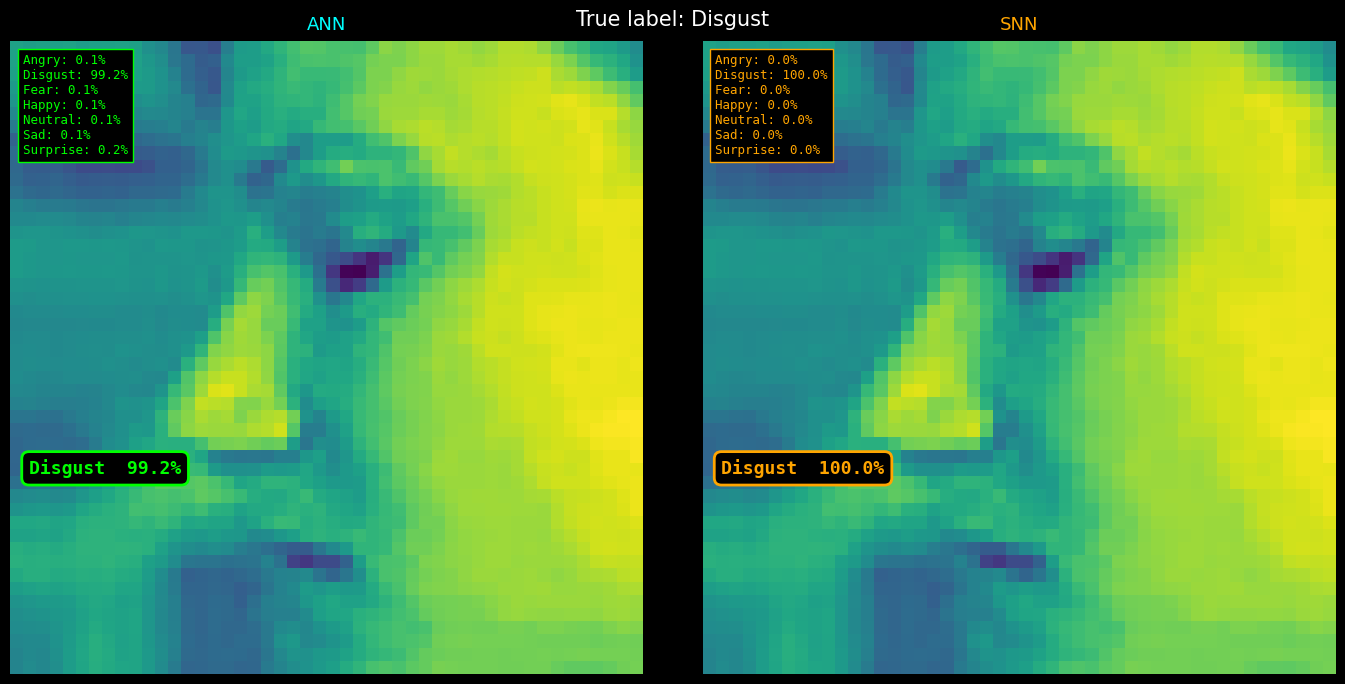

Saved : inference_result.png


In [21]:
# =================================================================
# USAGE
# =================================================================
# Single image:
test_image("/home/dieudo/ProjectsLIN/neuromorphic-emotion-recognition/data/train/disgust/Training_4844859.jpg")
#
# Random image from dataset:
#   test_random_image("/home/dieudo/ProjectsLIN/.../data")
# =================================================================